# L11: The transient Universe p.1
Read in solutions/transient.npy. This is a (100 x 3) numpy array, containing some time-series measurements from a transient phenomenon. The first column is time (arbitrary units), the second column is the flux (arbitrary units), and the third column are homoescedastic measurement uncertainties on the flux. Plot this data with the uncertainties.

In [1]:
import numpy as np
import dynesty
from matplotlib import pyplot as plt
import emcee
import corner
import time
from IPython.display import display, Math, Latex

In [2]:
path="/Users/francescarattegni/reps/astrostatistics_bicocca_2025/solutions"
file=path+"/transient.npy"
data=np.load(file)

In [3]:
t = data[:, 0]
flux = data[:, 1]
flux_err = data[:, 2]

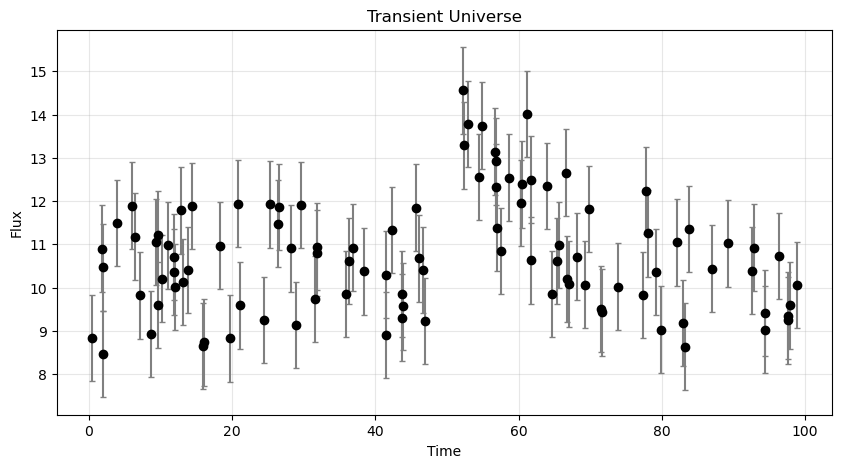

In [5]:
plt.figure(figsize=(10, 5))
plt.errorbar(t, flux, yerr=flux_err, fmt='o', color='black', ecolor='gray', capsize=2)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.title('Transient Universe')
plt.grid(True, alpha=0.3)
plt.show()

2. One possible model for this data is a sharp burst with an exponential tail rising above a nominal background level. This model can be described as: $$ y = b \quad \text{for} \quad t < t_0 $$ and $$ y = b + A \exp[-\alpha ( t - t_0)] \quad \text{for} \quad t > t_0 $$ where $b$ is the background amplitude, $A$ is the burst amplitude, $t_0$ is the burst epoch, and  encodes how rapidly the burst dies off. Code this burst model, and code a likelihood function for this data with the burst model.

In [6]:
# model
def model(theta, t):
    b, A, t0, ln_alpha = theta
    alpha = np.exp(ln_alpha)
    y = np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))
    return y

# Uniform priors:
#    b = Uniform[0, 50]
#    A = Uniform[0, 50]
#    t0 = Uniform[0, 100]
#    ln(alpha) = Uniform[-5, 5]

def log_prior(theta):
    b, A, t0, ln_alpha = theta
    if (0.0 <= b <= 50.0) and (0.0 <= A <= 50.0) and (0.0 <= t0 <= 100.0) and (-5.0 <= ln_alpha <= 5.0):
        return 0  #p(alpha) = p(ln_alpha) * |d(ln_alpha)/d(alpha)| = 1 / alpha
    return -np.inf

def log_likelihood(theta, t, y, yerr):
    y_model = model(theta,t)
    return -0.5 * np.sum(((y - y_model)/yerr)**2 + np.log(2 * np.pi * yerr**2))

def log_posterior(theta, t, y, yerr):
# Log posterior = log prior + log likelihood.    
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, y, yerr)

3. Using one of the MCMC sampler (emcee, pymc), perform a Bayesian analysis that recovers an MCMC chain of posterior probability samples for the joint parameter space of $\{\alpha, b, A, t_0)$. You must decide on how many samples are appropriate for running your MCMC. For your priors, make them: $b \in \text{Uniform}[0,50]$, $A \in \text{Uniform}[0,50]$, $t_0 \in \text{Uniform}[0,100]$, $ln(\alpha) \in \text{Uniform}[-5,5]$

In [7]:
# Run MCMC with emcee
n_dim = 4  # number of parameters in the model: # b, A, t0, ln_alpha
n_walkers = 20  # number of MCMC walkers
n_steps = 10000  # number of MCMC steps to take for each walker

alpha_guess = 0.1
ln_alpha_guess = np.log(alpha_guess)
b_guess = np.median(flux[t < 40])
A_guess = np.max(flux) - b_guess
t0_guess = np.argmax(flux)
guess = [b_guess, A_guess, t0_guess, ln_alpha_guess]

starting_guesses = guess + 1e-2 * np.random.randn(n_walkers, n_dim)
print(starting_guesses.shape)

(20, 4)


In [8]:
sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, args=(t, flux, flux_err))
sampler.run_mcmc(starting_guesses, n_steps, progress=True);

100%|███████████████████████████████████| 10000/10000 [00:03<00:00, 2954.53it/s]


4. Perform an appropriate check to burn-in your chain, and thin the chain by selecting only points every auto-correlation length. If you are left with a small number of samples after thinning then you may need to run your MCMC for longer in (3).

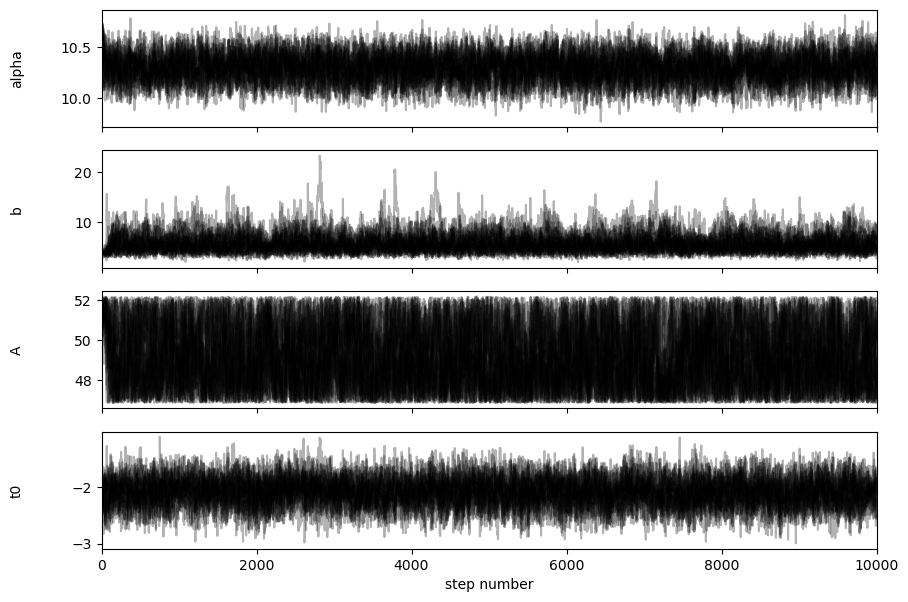

In [9]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["alpha","b","A","t0"]
for i in range(n_dim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

5. Make a corner plot of the 4-D parameter space, with labels, $[68,95]\%$ credible levels and quantiles, and titles.

In [10]:
tau = sampler.get_autocorr_time()
print(f"Autocorrelation times: {tau}")
print(f"Max autocorrelation time: {np.max(tau):.1f}")

burnin = int(3 * np.max(tau))
thin = int(np.max(tau))
print(f"Burn-in: {burnin} steps")
print(f"Thinning: every {thin} steps")

Autocorrelation times: [60.53676948 85.16499217 76.47833396 70.47528103]
Max autocorrelation time: 85.2
Burn-in: 255 steps
Thinning: every 85 steps


In [11]:
flat_samples = sampler.get_chain(discard=burnin, thin=thin, flat=True)
print(f"Number of independent samples: {flat_samples.shape[0]}")

Number of independent samples: 2280


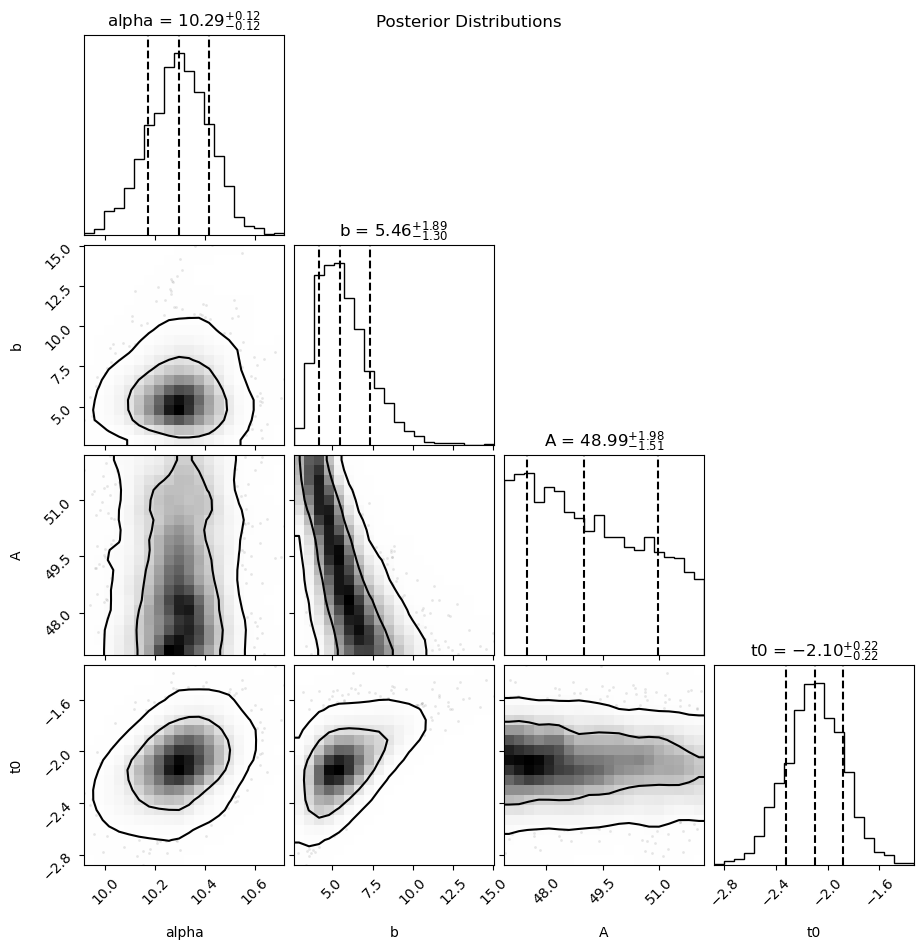

In [12]:
fig = corner.corner(
    flat_samples,
    labels=labels,
    show_titles=True,
    quantiles=[0.16, 0.5, 0.84],
    title_kwargs={"fontsize": 12},
    levels=(0.68, 0.95),
    plot_contours=True,
    smooth=1.0
)
fig.suptitle('Posterior Distributions')
plt.show()

6. Now choose 100 samples randomly from your burned, thinned chain and plot the 100 corresponding burst time-series on a figure along with the original data. You may want to choose a transparency for these 100 burst curves that allows you to see everything nicely. These are showing the posterior spread of model solutions that are consistent with the data.

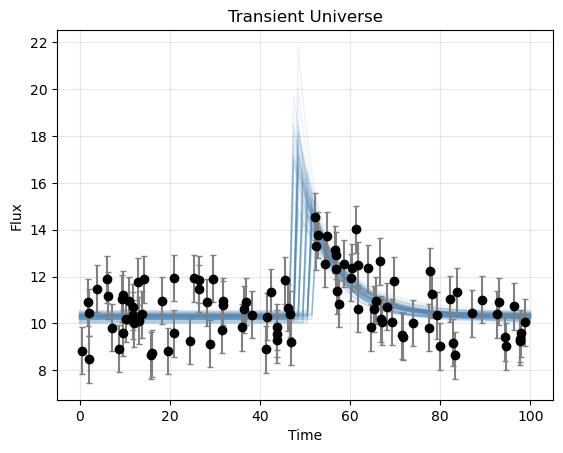

In [13]:
# Select 100 random samples from the thinned chain
n_samples = 100
idx = np.random.choice(len(flat_samples), size=n_samples, replace=False)
samples_to_plot = flat_samples[idx]

tgrid=np.linspace(0,100,100)
for sample in samples_to_plot:
    b, A, t0, ln_alpha = sample
    alpha = np.exp(ln_alpha)
    model_curve = model(sample, tgrid)
    plt.plot(tgrid, model_curve, color='steelblue', alpha=0.1, lw=1)
plt.errorbar(t, flux, yerr=flux_err, fmt='o', color='black', ecolor='gray', capsize=2)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.title('Transient Universe')
plt.grid(True, alpha=0.3)
plt.show()

7. For each parameter, find the median and $90\%$ credible region of the marginalized distribution and quote results as, for instance, $ t_0 = X^{+Y}_{-Z}$


In [14]:
def credible_interval(samples, level=0.90):
    """Compute median and symmetric credible interval."""
    lower = (1 - level) / 2
    upper = 1 - lower
    q_low, median, q_high = np.percentile(samples, [100*lower, 50, 100*upper])
    return median, q_high - median, median - q_low

print("PARAMETER ESTIMATES (median with 90% credible intervals)")
param_names = ['b', 'A', 't_0', r'\ln\alpha']
for i, name in enumerate(param_names):
    med, plus, minus = credible_interval(flat_samples[:, i], level=0.90)
    display(Math(f"{name} = {med:.3f}^{{+{plus:.3f}}}_{{-{minus:.3f}}}"))
# Also compute alpha itself (not ln_alpha)
alpha_samples = np.exp(flat_samples[:, 3])
med_alpha, plus_alpha, minus_alpha = credible_interval(alpha_samples, level=0.90)
display(Math(f"\n \\alpha = {med_alpha:.3f}^{{+{plus_alpha:.3f}}}_{{-{minus_alpha:.3f}}}"))

PARAMETER ESTIMATES (median with 90% credible intervals)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>